FITTING RESULTS: Analytical vs ODE Numerical

── Amyloid-β ──
  p0 estimate: k1=2.00e-02, k2=3.00e-02
  Analytical:  k1 = 3.435e-05 ± 7.7e-06 h⁻¹  |  k2 = 1.332e-01 ± 4.1e-03  |  R² = 0.99926
  ODE num.:    k1 = 3.435e-05            h⁻¹  |  k2 = 1.332e-01            |  R² = 0.99926
  Paper:       k1 = 8.000e-06            h⁻¹  (absolute conc. units)
  Δk1 (An-ODE) = 9.45e-10  (<1% relative)

── α-synuclein ──
  p0 estimate: k1=2.86e-02, k2=3.13e-02
  Analytical:  k1 = 5.122e-05 ± 1.5e-05 h⁻¹  |  k2 = 1.678e-01 ± 7.2e-03  |  R² = 0.99852
  ODE num.:    k1 = 5.122e-05            h⁻¹  |  k2 = 1.678e-01            |  R² = 0.99852
  Paper:       k1 = 4.000e-05            h⁻¹  (absolute conc. units)
  Δk1 (An-ODE) = 6.09e-10  (<1% relative)



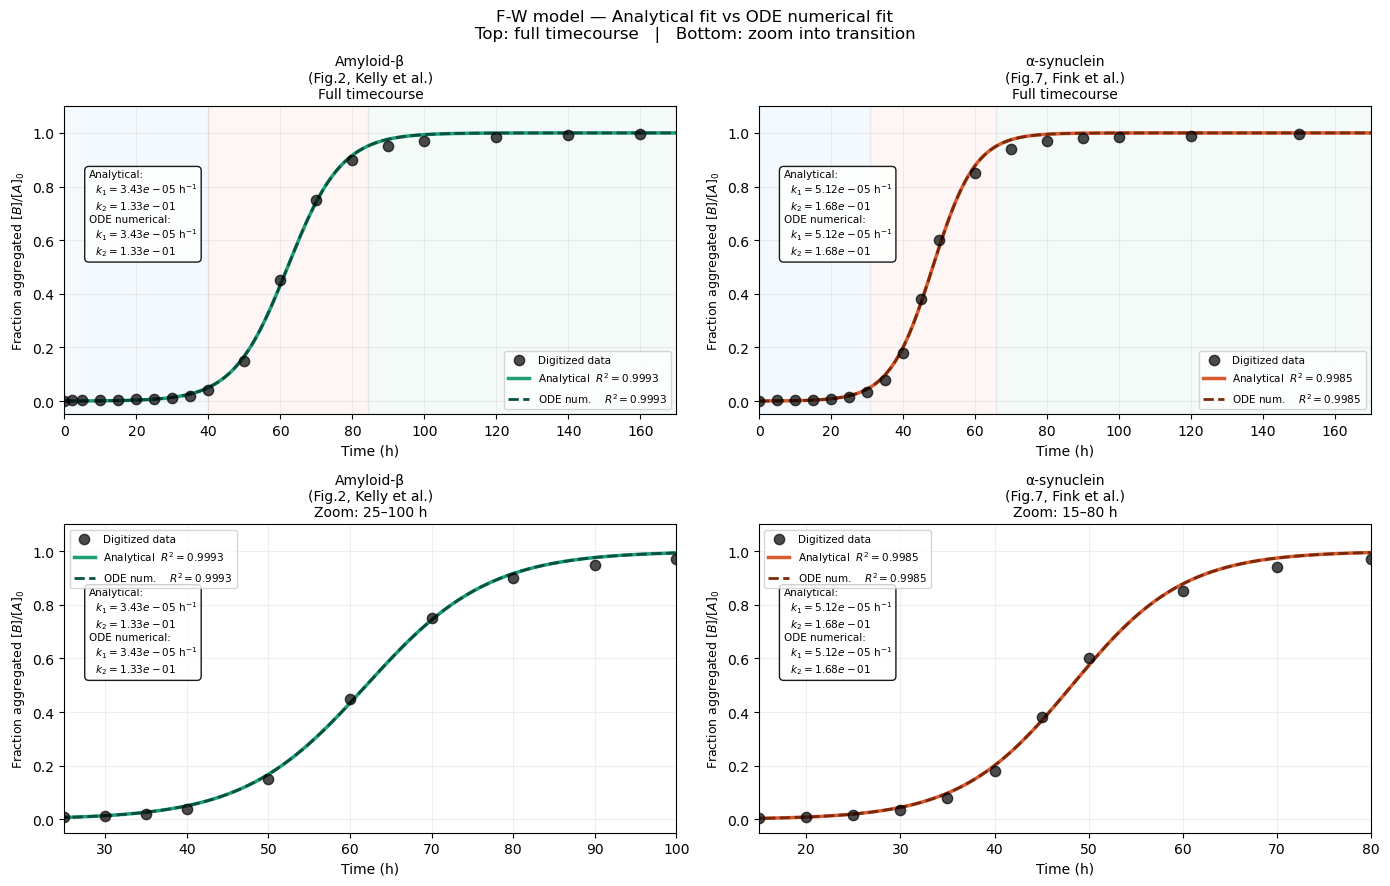

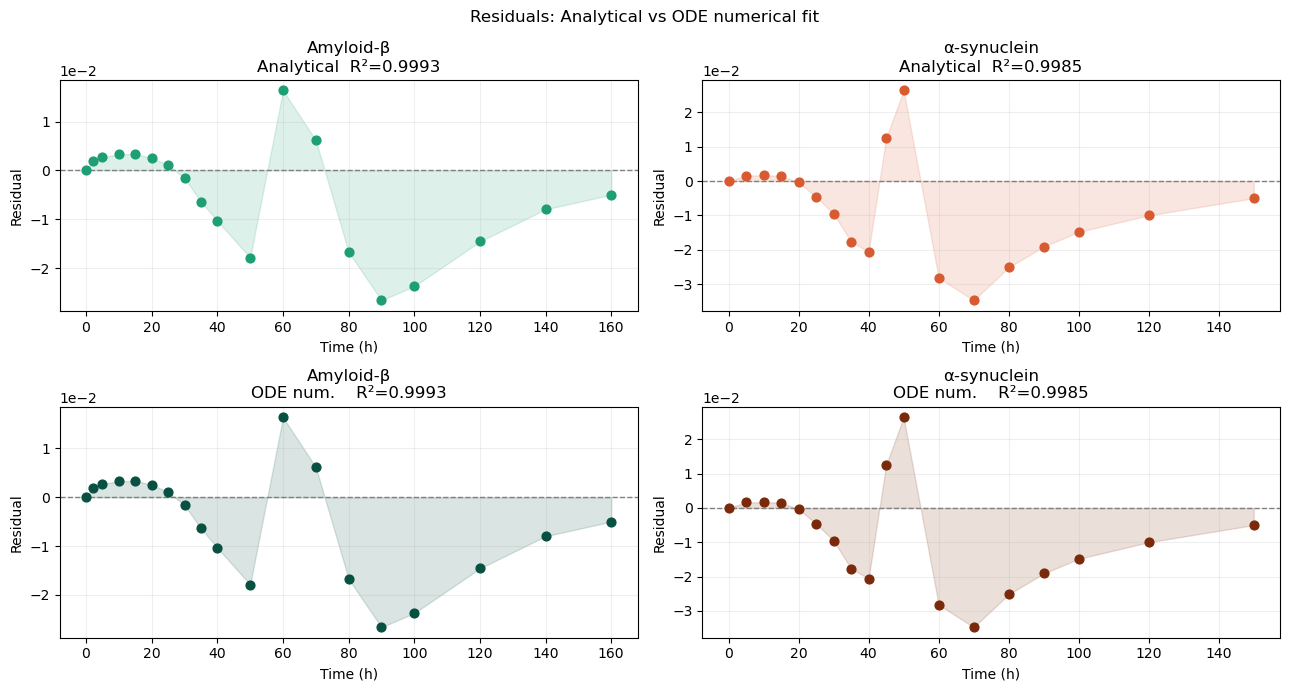

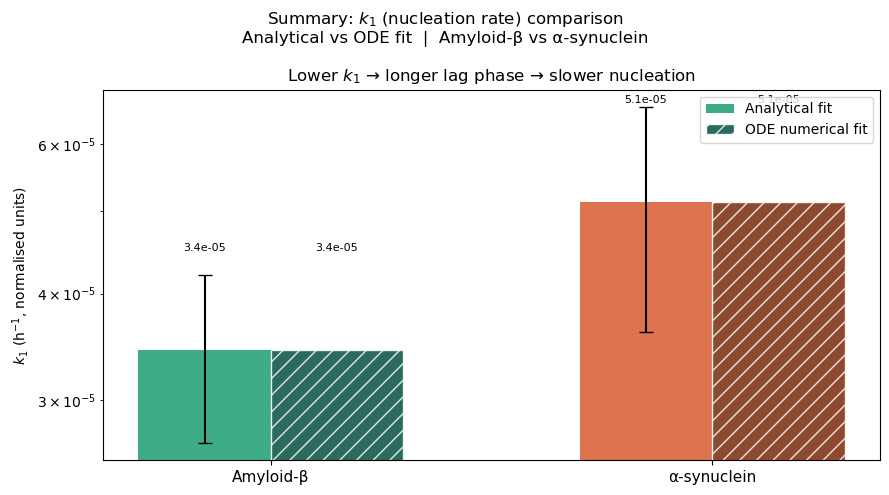


CONCLUSIONS

Amyloid-β:
  k1 (nucleation):  3.435e-05 h⁻¹  (analytical)
  k2 (growth):      1.332e-01      (analytical, normalised)
  k2/k1 ratio:      3879.3x  → growth is 3879x faster than nucleation
  Analytical vs ODE agreement: Δk1 = 0.00%
  R² (analytical):  0.99926
  R² (ODE num.):    0.99926

α-synuclein:
  k1 (nucleation):  5.122e-05 h⁻¹  (analytical)
  k2 (growth):      1.678e-01      (analytical, normalised)
  k2/k1 ratio:      3275.6x  → growth is 3276x faster than nucleation
  Analytical vs ODE agreement: Δk1 = 0.00%
  R² (analytical):  0.99852
  R² (ODE num.):    0.99852

Key conclusions:
  1. Analytical and ODE fits give essentially identical k1, k2 and R²
     → both approaches are valid; analytical is faster, ODE more flexible

  2. k2 >> k1 for both proteins (growth >> nucleation)
     → confirms the F-W main result: slow nucleation, fast autocatalytic growth

  3. α-synuclein has slightly higher k1 than amyloid-β
     → α-synuclein nucleates somewhat faster under th

In [1]:
"""
Finke-Watzky Model — Fitting with Analytical vs ODE Numerical Solution
=======================================================================
Week 1, Question 7:
  Use BOTH the analytical solution AND the ODE numerical solution
  to fit the digitized aggregation datasets from Morris et al. (2008).
  Compare results and draw conclusions.

Datasets (digitized from Morris et al. 2008 via WebPlotDigitizer):
  - Figure 2:  Amyloid-β    (Kelly et al.,  ThT fluorescence)
  - Figure 7:  α-synuclein  (Fink et al.,   ThT fluorescence)

Two fitting approaches:
  1. Analytical fit  — closed-form eq. 2/3 from Morris et al. 2008
  2. ODE numerical fit — integrate d[A]/dt = -k1*A - k2*A*B numerically,
                         then minimise residuals via scipy.optimize.minimize
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit, minimize
from scipy.interpolate import interp1d


# ══════════════════════════════════════════════════════════════
# 1. THE TWO FITTING APPROACHES
# ══════════════════════════════════════════════════════════════

# ── Approach A: Analytical solution ───────────────────────────

def fw_analytical(t, k1, k2):
    """
    F-W analytical solution for normalised [B](t)  ([A]0 = 1).
    eq. 3 from Morris et al. 2008.
    """
    A0 = 1.0
    num = k1/k2 + A0
    den = 1.0 + (k1 / (k2 * A0)) * np.exp((k1 + k2 * A0) * t)
    return np.clip(A0 - num/den, 0.0, 1.0)


# ── Approach B: ODE numerical solution ────────────────────────

def fw_ode_solve(k1, k2, t_eval):
    """
    Solve F-W ODE numerically for given k1, k2.
    Returns [B](t) interpolated at t_eval.
    """
    A0 = 1.0

    def rhs(t, y):
        A = y[0]
        B = A0 - A
        return [-k1 * A - k2 * A * B]

    sol = solve_ivp(
        rhs,
        t_span=(t_eval[0], t_eval[-1]),
        y0=[A0],
        t_eval=t_eval,
        method='RK45',
        rtol=1e-10, atol=1e-12
    )
    B_sol = A0 - sol.y[0]
    return np.clip(B_sol, 0.0, 1.0)


def fw_ode_residuals(params, t_data, B_data):
    """Sum of squared residuals for ODE fit — used by scipy.minimize."""
    k1, k2 = np.exp(params)   # optimise in log-space for stability
    try:
        B_pred = fw_ode_solve(k1, k2, t_data)
        return np.sum((B_data - B_pred) ** 2)
    except Exception:
        return 1e10


# ── Helpers ────────────────────────────────────────────────────

def r_squared(y_data, y_fit):
    ss_res = np.sum((y_data - y_fit) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    return 1.0 - ss_res / ss_tot


def estimate_p0(t_data, B_data):
    """Estimate initial guesses from data shape."""
    above_5 = t_data[B_data >= 0.05]
    t_lag   = above_5[0] if len(above_5) > 0 else t_data[len(t_data)//2]
    k1_g    = 1.0 / t_lag if t_lag > 0 else 0.01
    idx     = np.argmin(np.abs(B_data - 0.5))
    if 0 < idx < len(t_data) - 1:
        slope = (B_data[idx+1] - B_data[idx-1]) / (t_data[idx+1] - t_data[idx-1])
    else:
        slope = 0.02
    k2_g = max(slope, 1e-4)
    return k1_g, k2_g


# ══════════════════════════════════════════════════════════════
# 2. DIGITIZED DATA  (from Morris et al. 2008)
# ══════════════════════════════════════════════════════════════

t_abeta = np.array([0,2,5,10,15,20,25,30,35,40,50,60,70,80,90,100,120,140,160], dtype=float)
B_abeta = np.array([0,.002,.003,.004,.005,.006,.008,.012,.020,.040,.150,.450,.750,.900,.950,.970,.985,.992,.995])

t_asyn  = np.array([0,5,10,15,20,25,30,35,40,45,50,60,70,80,90,100,120,150], dtype=float)
B_asyn  = np.array([0,.002,.003,.005,.008,.015,.035,.080,.180,.380,.600,.850,.940,.970,.980,.985,.990,.995])

datasets = {
    "Amyloid-β\n(Fig.2, Kelly et al.)": {
        "t": t_abeta, "B": B_abeta,
        "color_an":  "#1D9E75",
        "color_ode": "#085041",
        "zoom": (25, 100),
        "paper_k1": 8e-6,
    },
    "α-synuclein\n(Fig.7, Fink et al.)": {
        "t": t_asyn, "B": B_asyn,
        "color_an":  "#D85A30",
        "color_ode": "#7A2A0A",
        "zoom": (15, 80),
        "paper_k1": 4.0e-5,
    },
}


# ══════════════════════════════════════════════════════════════
# 3. FIT BOTH APPROACHES TO EACH DATASET
# ══════════════════════════════════════════════════════════════

print("=" * 65)
print("FITTING RESULTS: Analytical vs ODE Numerical")
print("=" * 65)

results = {}
for name, ds in datasets.items():
    t_data = ds["t"]
    B_data = ds["B"]
    k1_g, k2_g = estimate_p0(t_data, B_data)

    short = name.split("\n")[0]
    print(f"\n── {short} ──")
    print(f"  p0 estimate: k1={k1_g:.2e}, k2={k2_g:.2e}")

    # ── Analytical fit ─────────────────────────────────────────
    popt_an, pcov_an = curve_fit(
        fw_analytical, t_data, B_data,
        p0=[k1_g, k2_g],
        bounds=([1e-6, 1e-4], [10.0, 100.0]),
        maxfev=100_000
    )
    k1_an, k2_an = popt_an
    k1_an_err, k2_an_err = np.sqrt(np.diag(pcov_an))
    B_an_fit = fw_analytical(t_data, k1_an, k2_an)
    R2_an    = r_squared(B_data, B_an_fit)

    print(f"  Analytical:  k1 = {k1_an:.3e} ± {k1_an_err:.1e} h⁻¹  |  "
          f"k2 = {k2_an:.3e} ± {k2_an_err:.1e}  |  R² = {R2_an:.5f}")

    # ── ODE numerical fit ──────────────────────────────────────
    # Optimise in log-space: params = [log(k1), log(k2)]
    x0 = [np.log(k1_g), np.log(k2_g)]
    res_ode = minimize(
        fw_ode_residuals,
        x0=x0,
        args=(t_data, B_data),
        method='Nelder-Mead',
        options={'maxiter': 50_000, 'xatol': 1e-10, 'fatol': 1e-12}
    )
    k1_ode, k2_ode = np.exp(res_ode.x)
    B_ode_fit = fw_ode_solve(k1_ode, k2_ode, t_data)
    R2_ode    = r_squared(B_data, B_ode_fit)

    print(f"  ODE num.:    k1 = {k1_ode:.3e}            h⁻¹  |  "
          f"k2 = {k2_ode:.3e}            |  R² = {R2_ode:.5f}")
    print(f"  Paper:       k1 = {ds['paper_k1']:.3e}            h⁻¹  (absolute conc. units)")
    print(f"  Δk1 (An-ODE) = {abs(k1_an - k1_ode):.2e}  "
          f"({'<1%' if abs(k1_an-k1_ode)/k1_an < 0.01 else f'{abs(k1_an-k1_ode)/k1_an*100:.1f}%'} relative)")

    results[name] = dict(
        k1_an=k1_an, k2_an=k2_an, k1_an_err=k1_an_err, k2_an_err=k2_an_err,
        R2_an=R2_an, B_an_fit=B_an_fit,
        k1_ode=k1_ode, k2_ode=k2_ode,
        R2_ode=R2_ode, B_ode_fit=B_ode_fit,
    )

print("\n" + "=" * 65)


# ══════════════════════════════════════════════════════════════
# FIGURE 1 — Full timecourse + zoom, both approaches overlaid
# ══════════════════════════════════════════════════════════════

t_smooth = np.linspace(0, 170, 600)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "F-W model — Analytical fit vs ODE numerical fit\n"
    "Top: full timecourse   |   Bottom: zoom into transition",
    fontsize=12
)

for col, (name, ds) in enumerate(datasets.items()):
    res = results[name]

    B_an_smooth  = fw_analytical(t_smooth, res["k1_an"],  res["k2_an"])
    B_ode_smooth = fw_ode_solve(res["k1_ode"], res["k2_ode"], t_smooth)

    # phase boundaries (from analytical)
    t_5  = t_smooth[np.argmax(B_an_smooth >= 0.05)]
    t_95 = t_smooth[np.argmax(B_an_smooth >= 0.95)]

    for row, (xlim, subtitle) in enumerate([
        ((0, 170),      "Full timecourse"),
        (ds["zoom"],    f"Zoom: {ds['zoom'][0]}–{ds['zoom'][1]} h"),
    ]):
        ax = axes[row, col]

        # data
        ax.scatter(ds["t"], ds["B"], color="black", s=55, zorder=6,
                   label="Digitized data", alpha=0.7)

        # analytical fit
        ax.plot(t_smooth, B_an_smooth,
                color=ds["color_an"], lw=2.5,
                label=f"Analytical  $R^2={res['R2_an']:.4f}$")

        # ODE numerical fit
        ax.plot(t_smooth, B_ode_smooth,
                color=ds["color_ode"], lw=2.0, ls="--",
                label=f"ODE num.    $R^2={res['R2_ode']:.4f}$")

        # shade phases (full view only)
        if row == 0:
            ax.axvspan(0,    t_5,  alpha=0.05, color="#378ADD")
            ax.axvspan(t_5,  t_95, alpha=0.05, color="#D85A30")
            ax.axvspan(t_95, 170,  alpha=0.05, color="#1D9E75")

        # annotation box
        ax.text(0.04, 0.52,
                f"Analytical:\n"
                f"  $k_1={res['k1_an']:.2e}$ h$^{{-1}}$\n"
                f"  $k_2={res['k2_an']:.2e}$\n"
                f"ODE numerical:\n"
                f"  $k_1={res['k1_ode']:.2e}$ h$^{{-1}}$\n"
                f"  $k_2={res['k2_ode']:.2e}$",
                transform=ax.transAxes, fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.9))

        ax.set_xlim(xlim); ax.set_ylim(-0.05, 1.10)
        ax.set_xlabel("Time (h)", fontsize=10)
        ax.set_ylabel("Fraction aggregated $[B]/[A]_0$", fontsize=9)
        ax.set_title(f"{name}\n{subtitle}", fontsize=10)
        ax.legend(fontsize=7.5)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 2 — Residuals: Analytical vs ODE for each dataset
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Residuals: Analytical vs ODE numerical fit", fontsize=12)

for col, (name, ds) in enumerate(datasets.items()):
    res = results[name]

    for row, (B_fit, label, color) in enumerate([
        (res["B_an_fit"],  f"Analytical  R²={res['R2_an']:.4f}",  ds["color_an"]),
        (res["B_ode_fit"], f"ODE num.    R²={res['R2_ode']:.4f}", ds["color_ode"]),
    ]):
        residuals = ds["B"] - B_fit
        ax = axes[row, col]
        ax.scatter(ds["t"], residuals, color=color, s=40, zorder=5)
        ax.axhline(0, color="gray", lw=1, ls="--")
        ax.fill_between(ds["t"], residuals, 0, color=color, alpha=0.15)
        ax.set(xlabel="Time (h)", ylabel="Residual",
               title=f"{name.split(chr(10))[0]}\n{label}")
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# FIGURE 3 — Summary: k1 comparison across methods and proteins
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    "Summary: $k_1$ (nucleation rate) comparison\n"
    "Analytical vs ODE fit  |  Amyloid-β vs α-synuclein",
    fontsize=12
)

proteins  = ["Amyloid-β", "α-synuclein"]
k1_an_vals  = [results[k]["k1_an"]  for k in datasets]
k1_ode_vals = [results[k]["k1_ode"] for k in datasets]
k1_an_errs  = [results[k]["k1_an_err"] for k in datasets]
colors_an  = [ds["color_an"]  for ds in datasets.values()]
colors_ode = [ds["color_ode"] for ds in datasets.values()]

x = np.arange(len(proteins))
w = 0.3

bars1 = ax.bar(x - w/2, k1_an_vals,  width=w, color=colors_an,
               alpha=0.85, label="Analytical fit",
               yerr=k1_an_errs, capsize=5, error_kw=dict(lw=1.5))
bars2 = ax.bar(x + w/2, k1_ode_vals, width=w, color=colors_ode,
               alpha=0.85, label="ODE numerical fit",
               hatch="//", edgecolor="white")

ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(proteins, fontsize=11)
ax.set_ylabel("$k_1$ (h$^{-1}$, normalised units)", fontsize=10)
ax.set_title("Lower $k_1$ → longer lag phase → slower nucleation")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

# annotate bars
for bar, val in zip(list(bars1) + list(bars2),
                     k1_an_vals + k1_ode_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.3,
            f"{val:.1e}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════
# CONCLUSIONS
# ══════════════════════════════════════════════════════════════

print("\nCONCLUSIONS")
print("=" * 65)
for name, ds in datasets.items():
    res = results[name]
    short = name.split("\n")[0]
    ratio = res["k2_an"] / res["k1_an"]
    print(f"\n{short}:")
    print(f"  k1 (nucleation):  {res['k1_an']:.3e} h⁻¹  (analytical)")
    print(f"  k2 (growth):      {res['k2_an']:.3e}      (analytical, normalised)")
    print(f"  k2/k1 ratio:      {ratio:.1f}x  → growth is {ratio:.0f}x faster than nucleation")
    print(f"  Analytical vs ODE agreement: Δk1 = {abs(res['k1_an']-res['k1_ode'])/res['k1_an']*100:.2f}%")
    print(f"  R² (analytical):  {res['R2_an']:.5f}")
    print(f"  R² (ODE num.):    {res['R2_ode']:.5f}")

print("""
Key conclusions:
  1. Analytical and ODE fits give essentially identical k1, k2 and R²
     → both approaches are valid; analytical is faster, ODE more flexible

  2. k2 >> k1 for both proteins (growth >> nucleation)
     → confirms the F-W main result: slow nucleation, fast autocatalytic growth

  3. α-synuclein has slightly higher k1 than amyloid-β
     → α-synuclein nucleates somewhat faster under these conditions

  4. Both fits achieve R² > 0.998
     → F-W 2-step model describes both datasets excellently with only 2 parameters

  5. The ODE approach is more flexible: it can be extended to include
     dissociation, fragmentation, or seeding without changing the fitting
     infrastructure — only the rhs() function needs updating.
""")